# Import Libraries

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Load Dataset

In [34]:
df = pd.read_csv('blinkit_dataset.csv')
df

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,NaN,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,NaN,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,NaN,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,NaN,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,...,False,Pouch,300,482,28,73,2025-01-16,2026-05-13,NaN,On-Time
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,...,True,Box,1000,13,19,35,2024-01-11,2024-01-24,Cashback,On-Time
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,...,True,Bottle,1000,3,20,34,2025-08-08,2025-08-11,NaN,On-Time
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,114,18,...,False,Bottle,500,403,24,17,2023-11-11,2024-12-18,NaN,On-Time


## Exploratory Data Analysis

In [36]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [37]:
df['expiry_date'] = pd.to_datetime(df['expiry_date'], errors='coerce')

In [38]:
df.shape

(13000, 25)

In [39]:
df.describe()

,product_id,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,stock,sold_quantity,profit_margin_pct,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date
count,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000,13000
mean,6500.500000,267.303356,9.959231,240.735212,4.196931,255.000308,27.558769,110.140538,162.400077,22.652708,536.130769,397.555385,21.627769,43.380462,2024-10-26 17:02:50.584615680,2025-11-28 06:22:35.815384576
min,1.000000,10.180000,0.000000,8.140000,2.500000,1.000000,10.000000,52.000000,0.000000,5.000000,100.000000,2.000000,10.000000,0.000000,2023-10-28 00:00:00,2023-10-30 00:00:00
25%,3250.750000,122.972500,0.000000,108.790000,3.900000,138.000000,23.000000,95.000000,54.000000,13.900000,250.000000,13.000000,19.000000,22.000000,2024-04-28 00:00:00,2024-11-19 00:00:00
50%,6500.500000,220.240000,10.000000,197.185000,4.200000,219.000000,27.000000,110.000000,120.000000,22.900000,400.000000,231.000000,22.000000,38.000000,2024-10-24 00:00:00,2025-08-03 12:00:00
75%,9750.250000,350.500000,15.000000,316.882500,4.500000,355.000000,32.000000,125.000000,253.000000,31.400000,750.000000,564.000000,25.000000,63.000000,2025-04-29 00:00:00,2026-07-18 06:00:00
max,13000.000000,999.930000,30.000000,998.920000,5.000000,1050.000000,56.000000,169.000000,720.000000,40.000000,2000.000000,1825.000000,33.000000,100.000000,2025-10-27 00:00:00,2030-10-19 00:00:00
std,3752.921085,199.665148,8.575017,182.405552,0.475863,152.933513,7.139059,19.589137,132.742425,10.088389,406.997451,483.540218,3.928429,27.076935,NaN,NaN


In [40]:
df.nunique()

product_id           13000
product_name         12617
category                 8
brand                   28
price                11526
discount_pct             7
final_price          11451
rating                  26
num_reviews            743
delivery_time_min       46
city                    10
seller                   6
stock                  111
sold_quantity          601
profit_margin_pct      351
is_organic               2
packaging_type           6
weight_g                10
shelf_life_days       1676
reorder_level           24
demand_index           101
date_added             731
expiry_date           2202
offer_type               4
delivery_status          2
dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         13000 non-null  int64         
 1   product_name       13000 non-null  object        
 2   category           13000 non-null  object        
 3   brand              13000 non-null  object        
 4   price              13000 non-null  float64       
 5   discount_pct       13000 non-null  int64         
 6   final_price        13000 non-null  float64       
 7   rating             13000 non-null  float64       
 8   num_reviews        13000 non-null  int64         
 9   delivery_time_min  13000 non-null  int64         
 10  city               13000 non-null  object        
 11  seller             13000 non-null  object        
 12  stock              13000 non-null  int64         
 13  sold_quantity      13000 non-null  int64         
 14  profit

In [42]:
df.isna().sum()

product_id              0
product_name            0
category                0
brand                   0
price                   0
discount_pct            0
final_price             0
rating                  0
num_reviews             0
delivery_time_min       0
city                    0
seller                  0
stock                   0
sold_quantity           0
profit_margin_pct       0
is_organic              0
packaging_type          0
weight_g                0
shelf_life_days         0
reorder_level           0
demand_index            0
date_added              0
expiry_date             0
offer_type           6544
delivery_status         0
dtype: int64

In [43]:
df.duplicated().sum()

0

In [44]:
df.fillna(0, inplace=True)
df

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,0,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,0,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,0,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,0,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,...,False,Pouch,300,482,28,73,2025-01-16,2026-05-13,0,On-Time
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,...,True,Box,1000,13,19,35,2024-01-11,2024-01-24,Cashback,On-Time
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,...,True,Bottle,1000,3,20,34,2025-08-08,2025-08-11,0,On-Time
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,114,18,...,False,Bottle,500,403,24,17,2023-11-11,2024-12-18,0,On-Time


In [45]:
num_cols = ['price', 'discount_pct', 'final_price', 'rating', 'num_reviews', 'delivery_time_min', 'stock', 'sold_quantity', 'profit_margin_pct', 'weight_g', 'shelf_life_days', 'reorder_level', 'demand_index']

cat_cols = ['category', 'brand', 'city', 'seller', 'packaging_type', 'offer_type', 'delivery_status', 'is_organic']

print(len(num_cols))
print(len(cat_cols))

13
8


## Visualization

### 1. Histogram Of Num_Cols

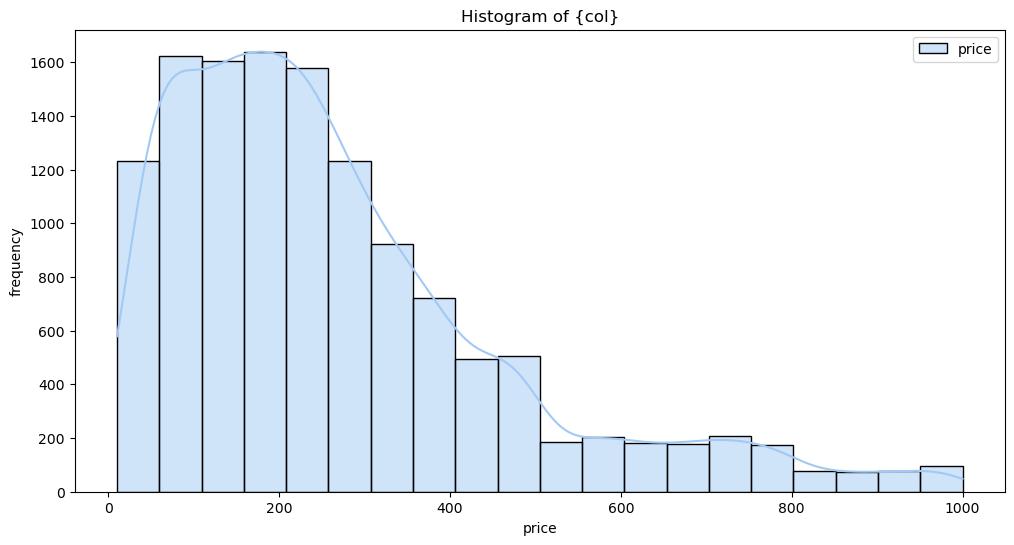

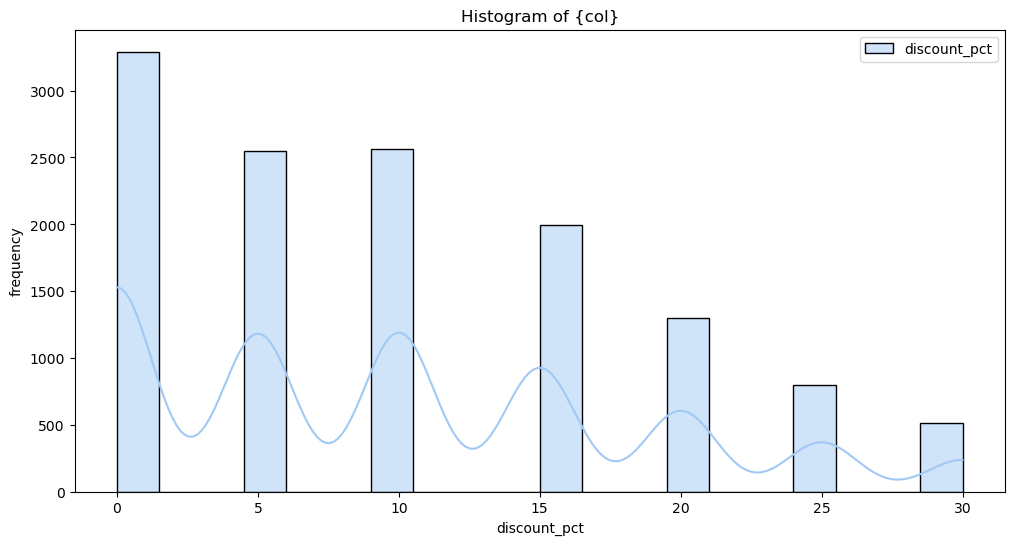

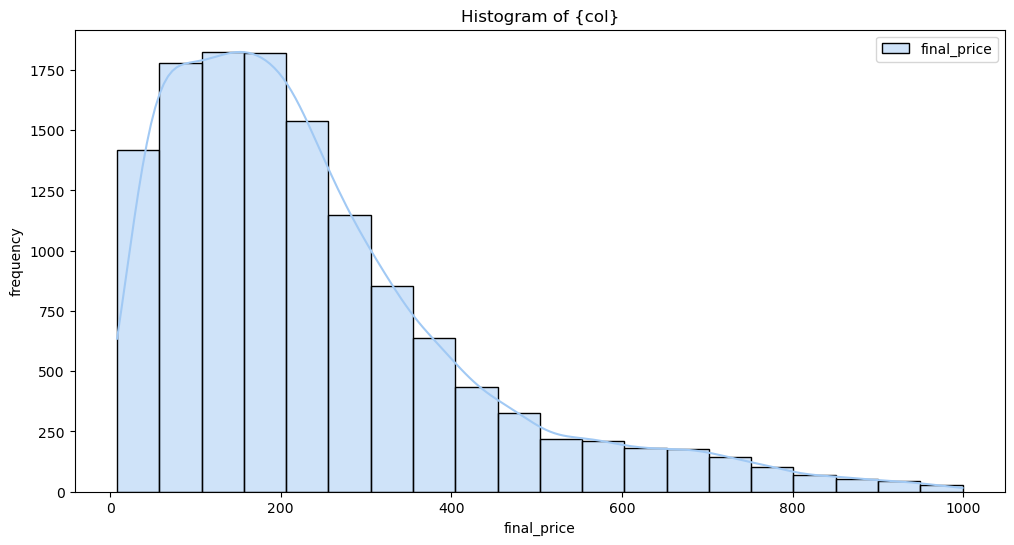

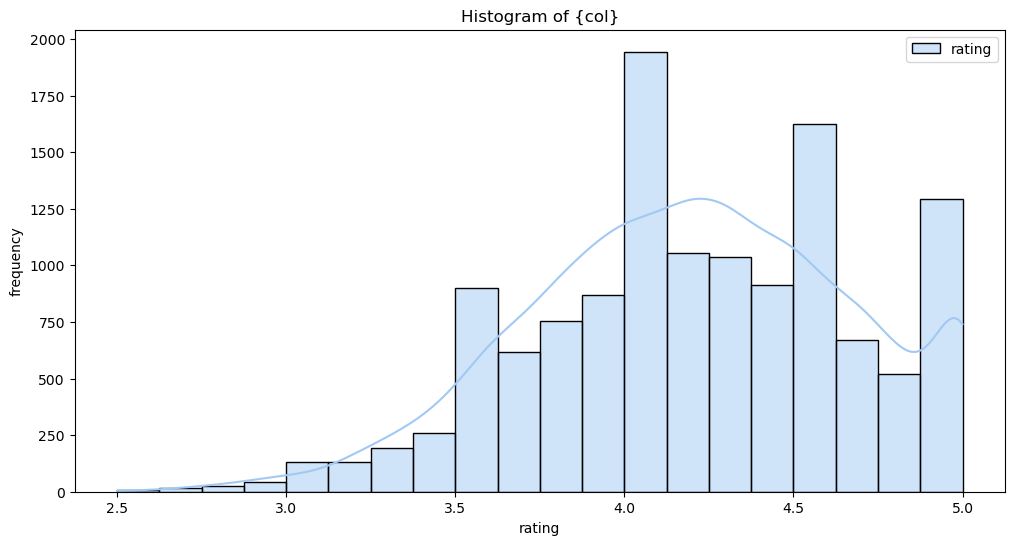

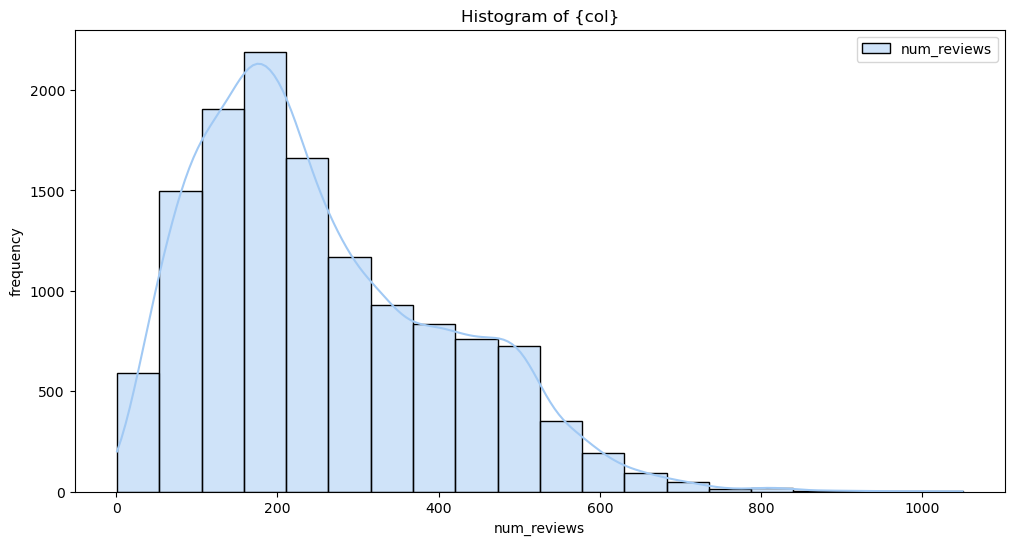

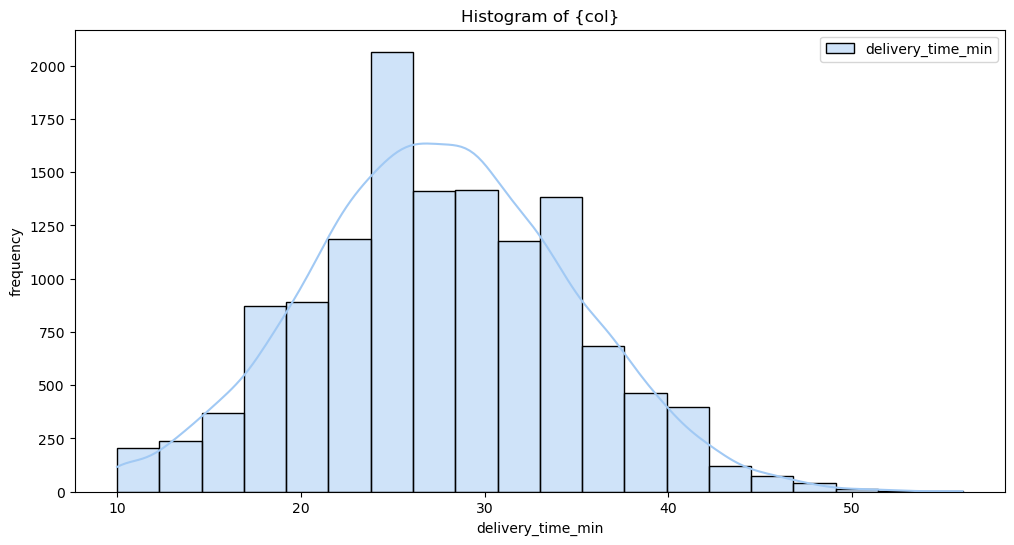

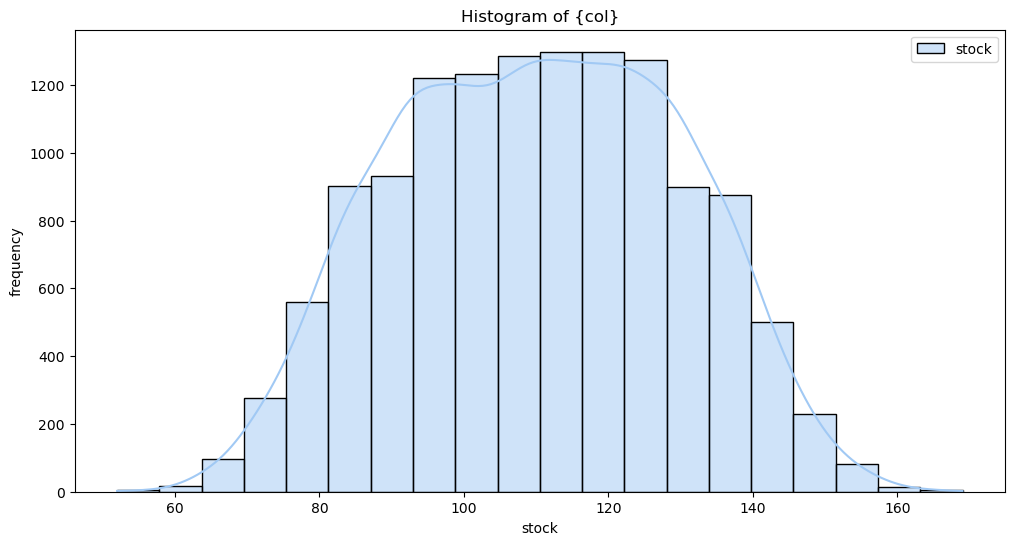

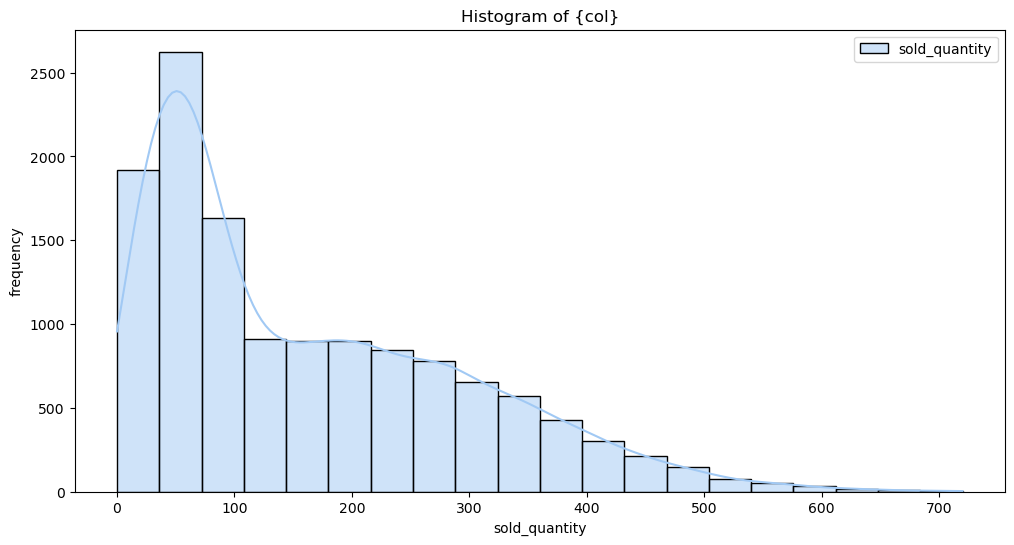

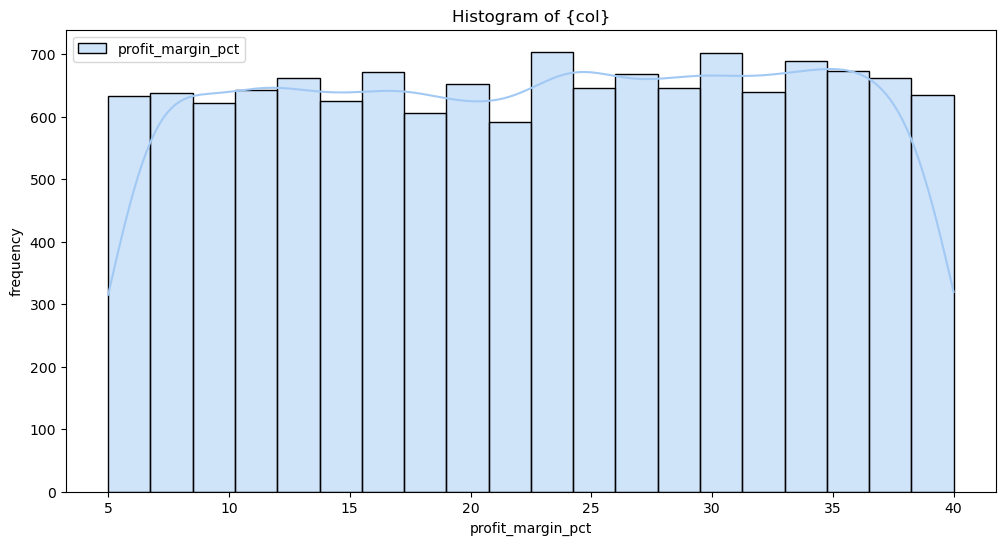

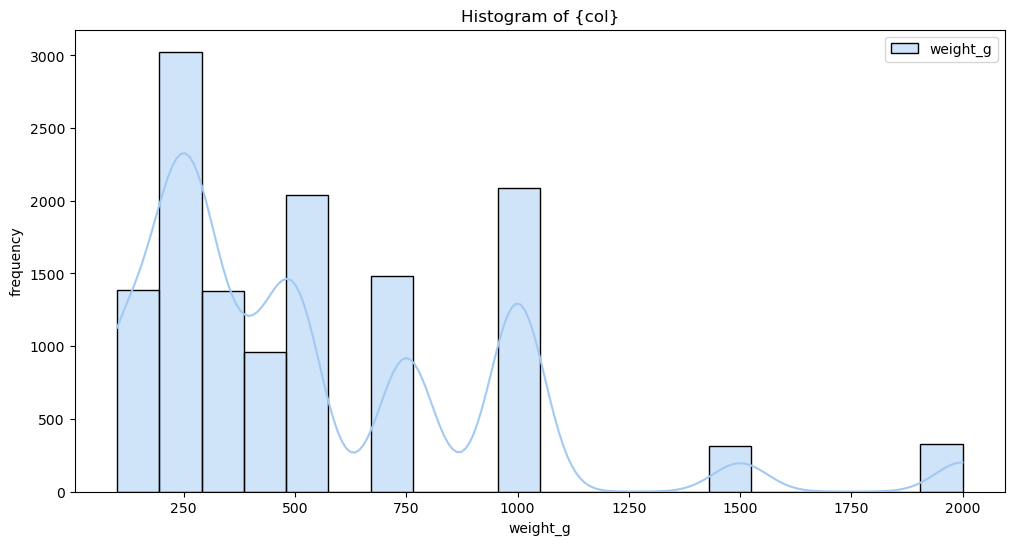

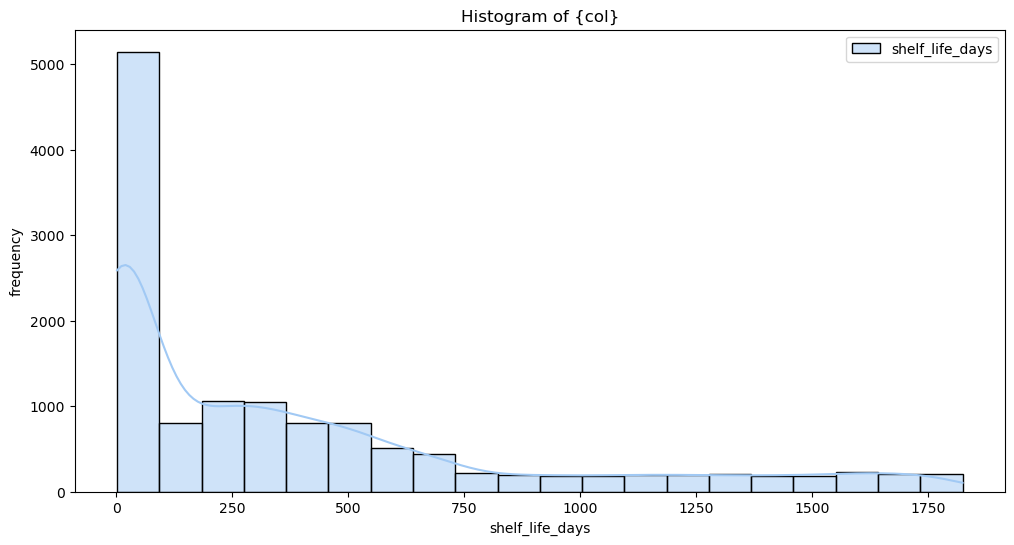

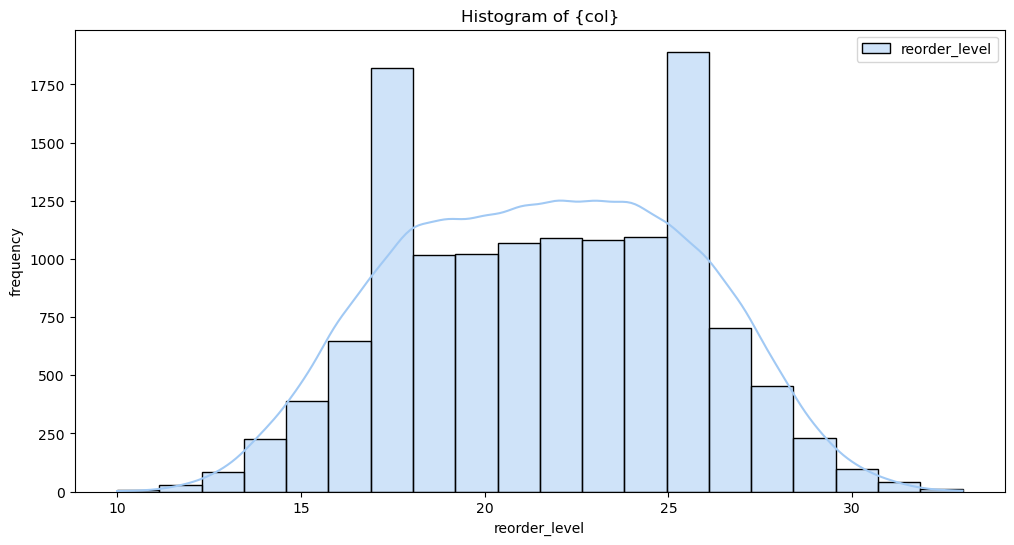

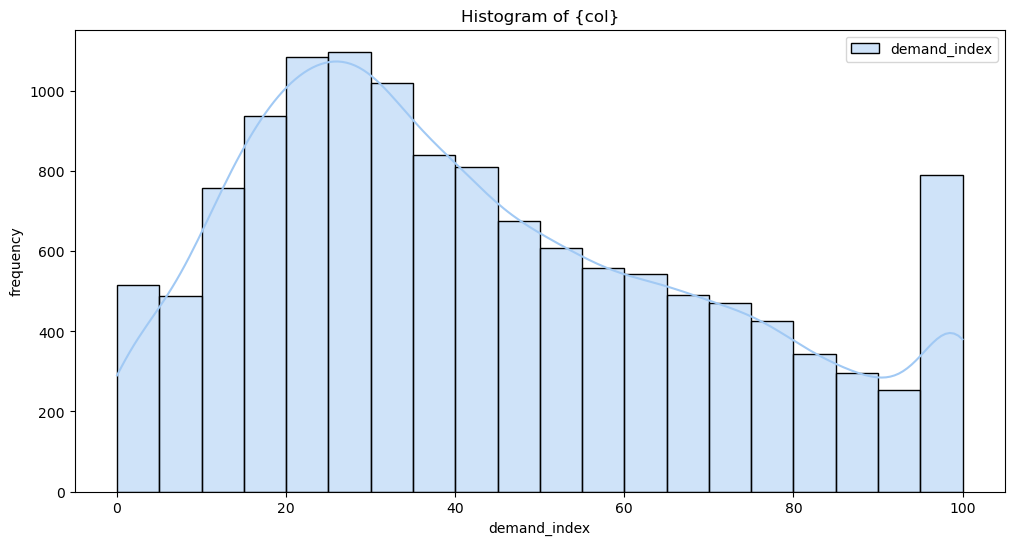

In [46]:
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[[col]], kde=True, palette='pastel', bins=20)
    plt.title('Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.tight_layout
    plt.show()

### 2. Countplot Of Cat_Cols

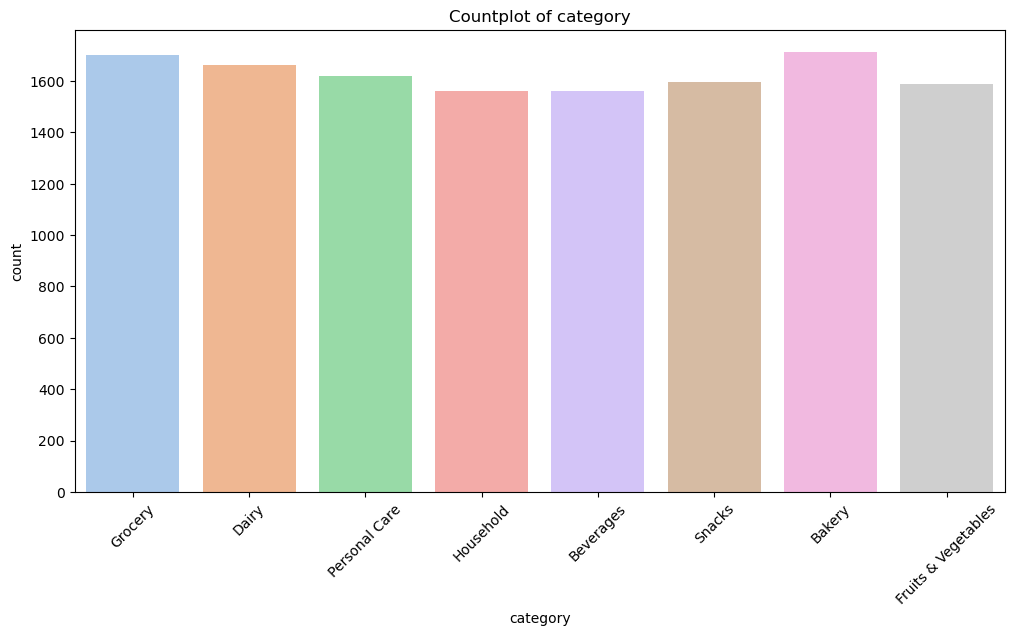

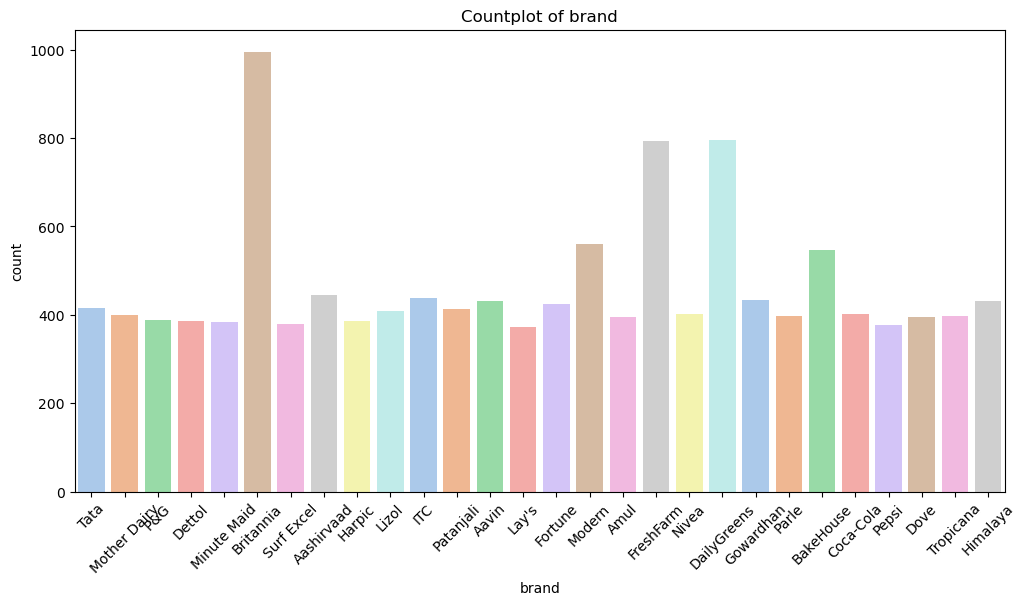

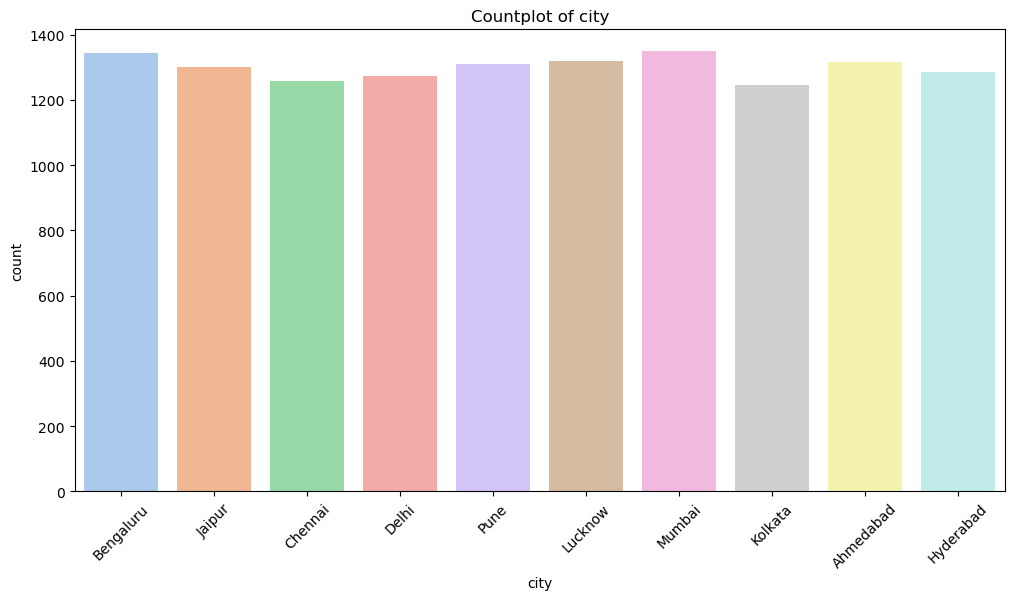

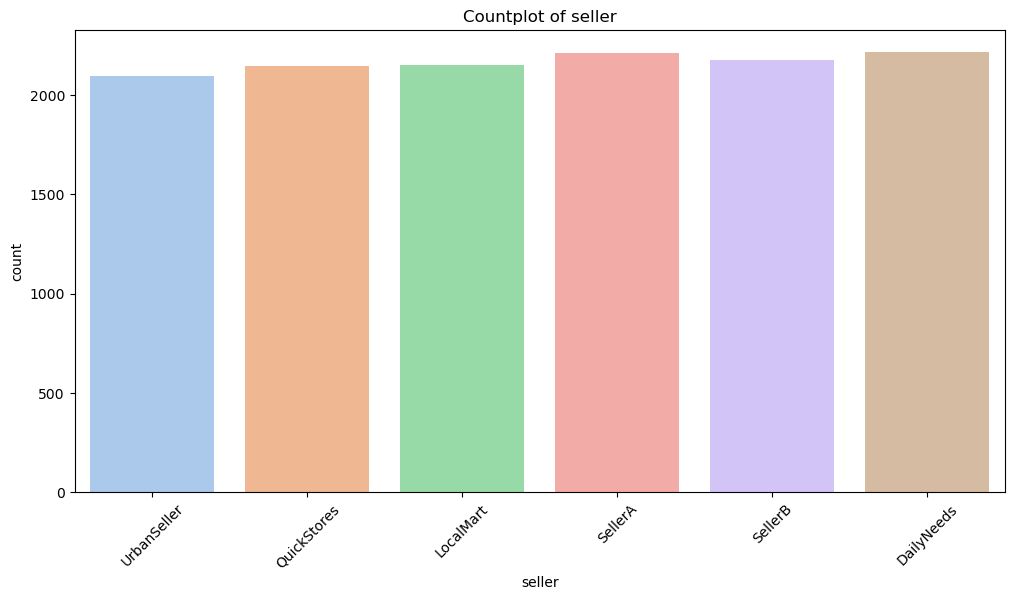

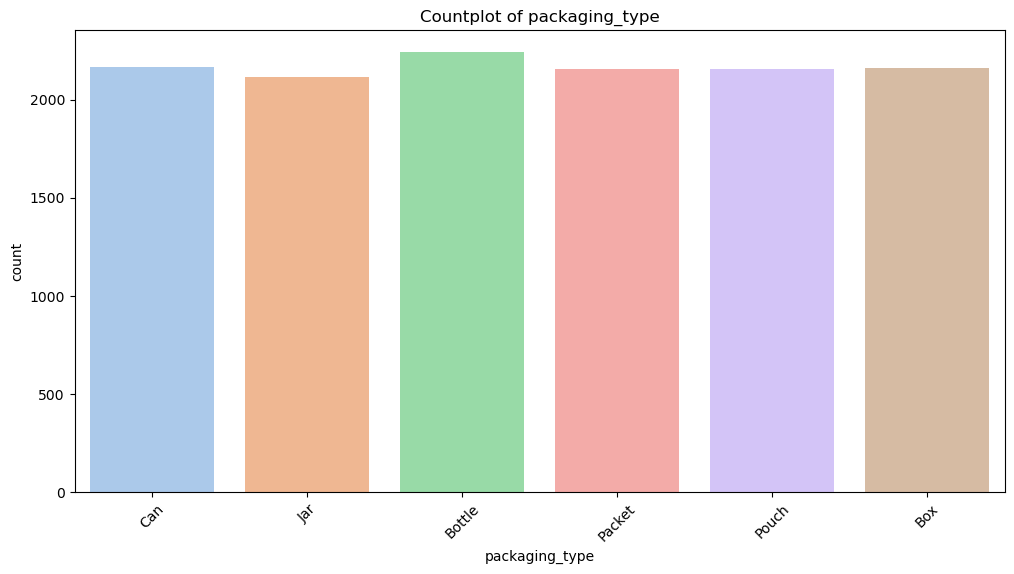

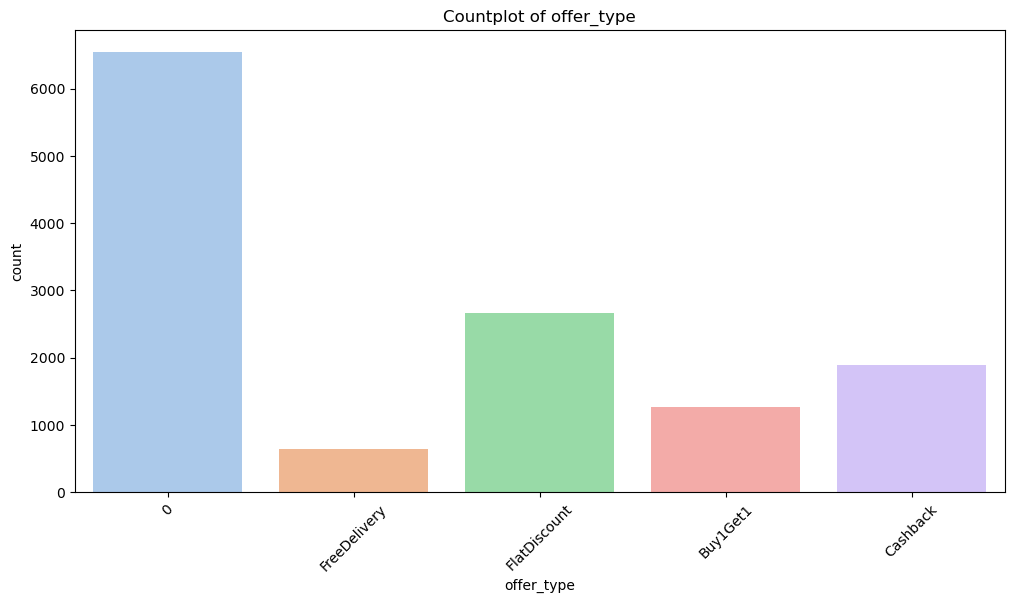

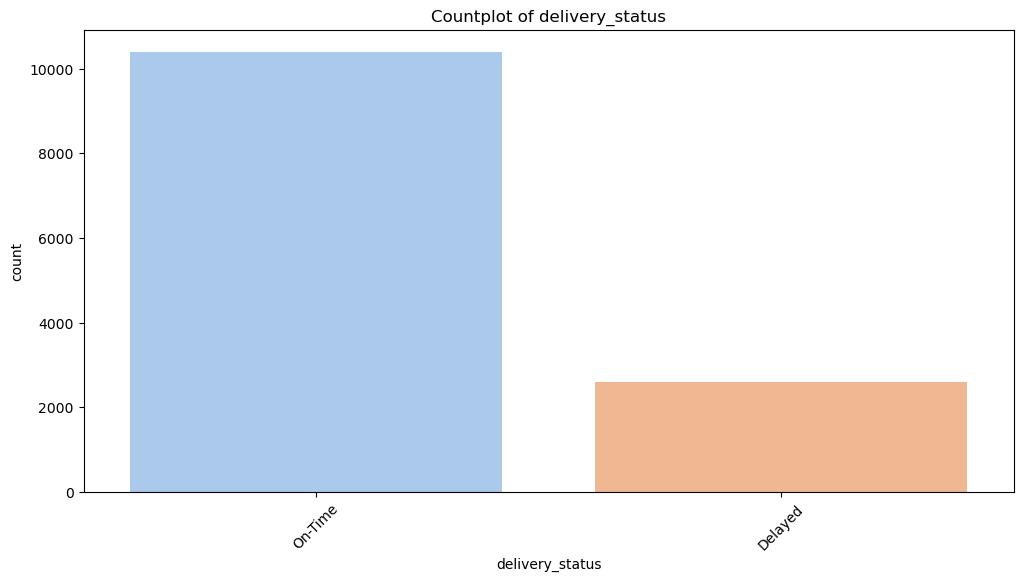

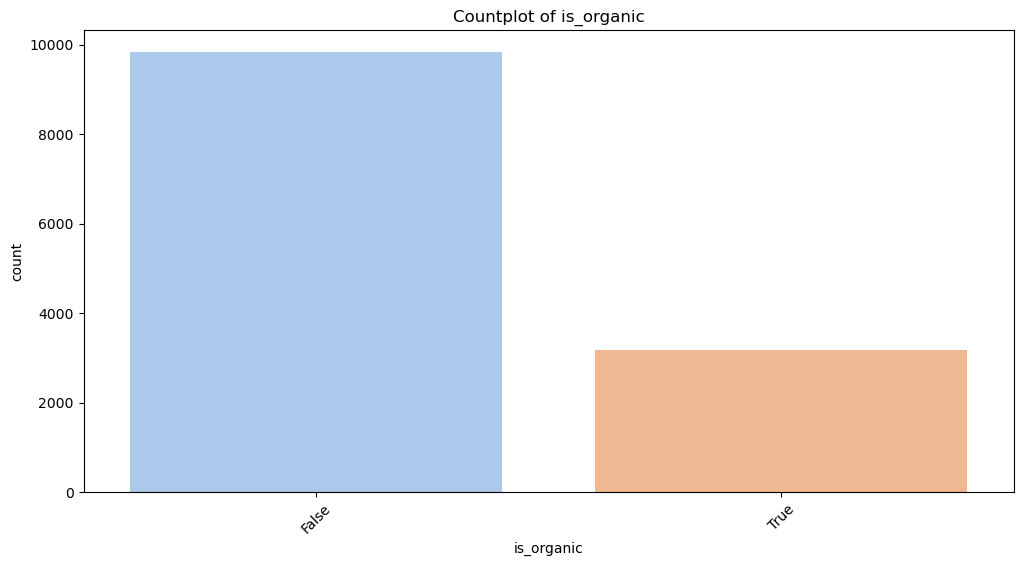

In [47]:
for col in cat_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=col, palette='pastel')
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.xticks(rotation=45)
    plt.tight_layout
    plt.show()

### 3. Final Price vs Sold Quantity by Organic

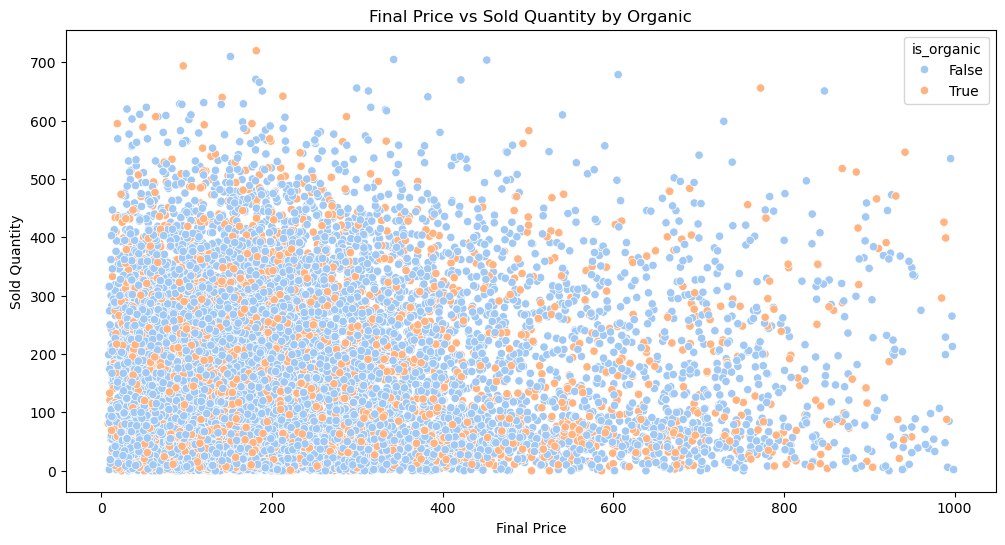

In [48]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['final_price'], y=df['sold_quantity'], hue=df['is_organic'], palette='pastel')
plt.title('Final Price vs Sold Quantity by Organic')
plt.xlabel('Final Price')
plt.ylabel('Sold Quantity')
plt.show()

### 4. Profit Margin Over Time

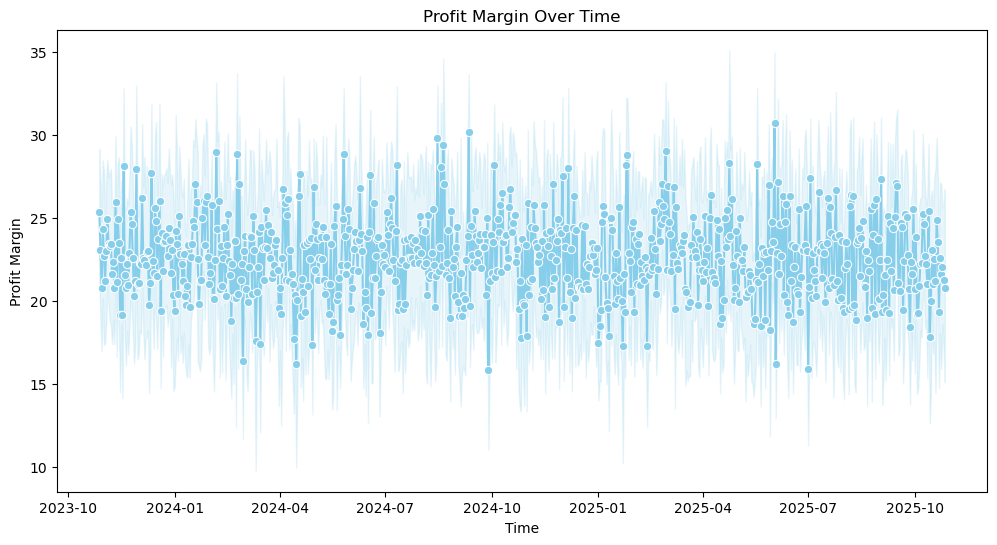

In [49]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['date_added'], y=df['profit_margin_pct'], marker='o', color='#87CEEB')
plt.title('Profit Margin Over Time')
plt.xlabel('Time')
plt.ylabel('Profit Margin')
plt.show()

### 5. Distribution Of Re-Order vs Demand Index

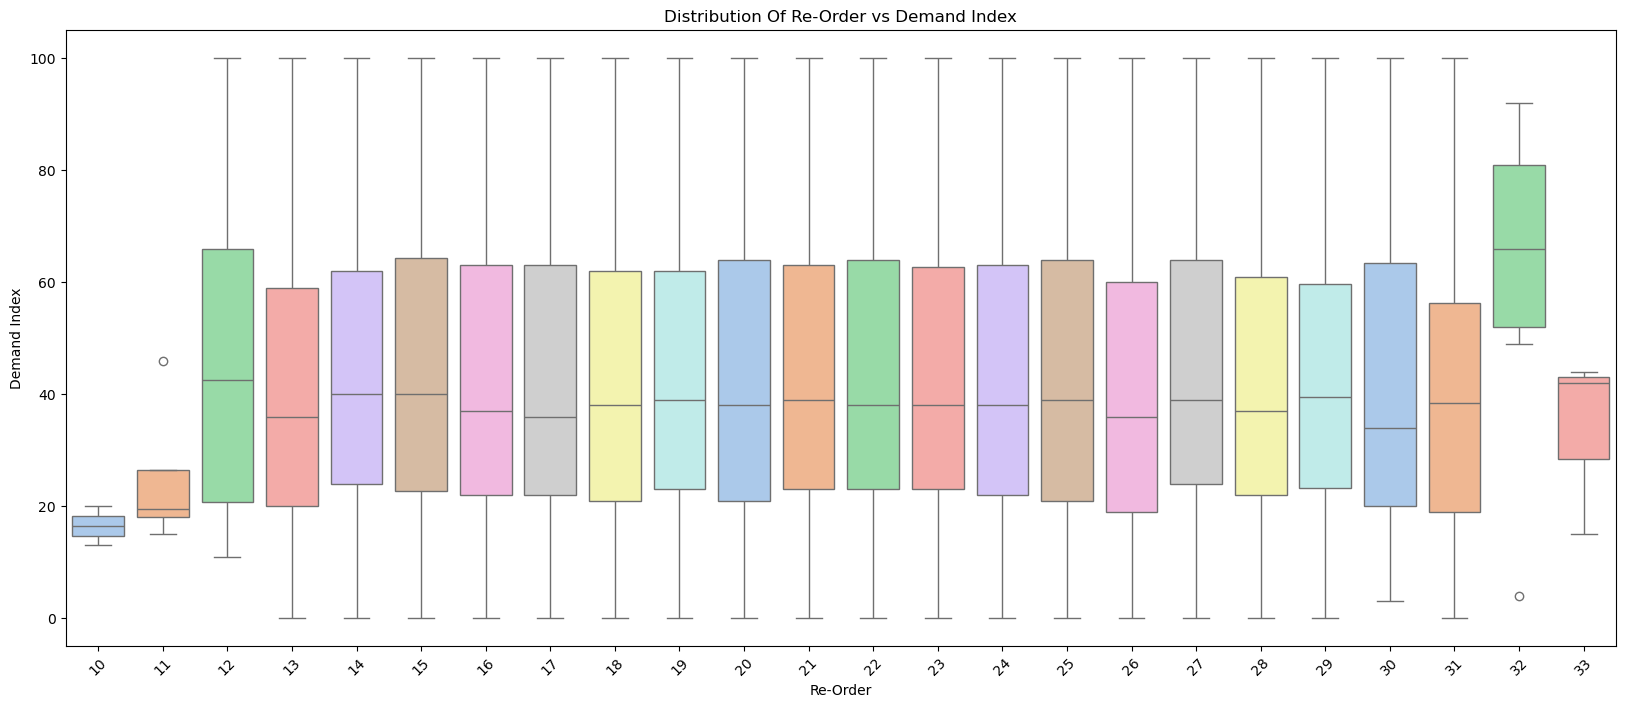

In [50]:
plt.figure(figsize=(20, 8))
sns.boxplot(x=df['reorder_level'], y=df['demand_index'], data=df, palette='pastel')
plt.title('Distribution Of Re-Order vs Demand Index')
plt.xlabel('Re-Order')
plt.ylabel('Demand Index')
plt.xticks(rotation=45)
plt.show()

### 6. Profit Margin Pct by Category

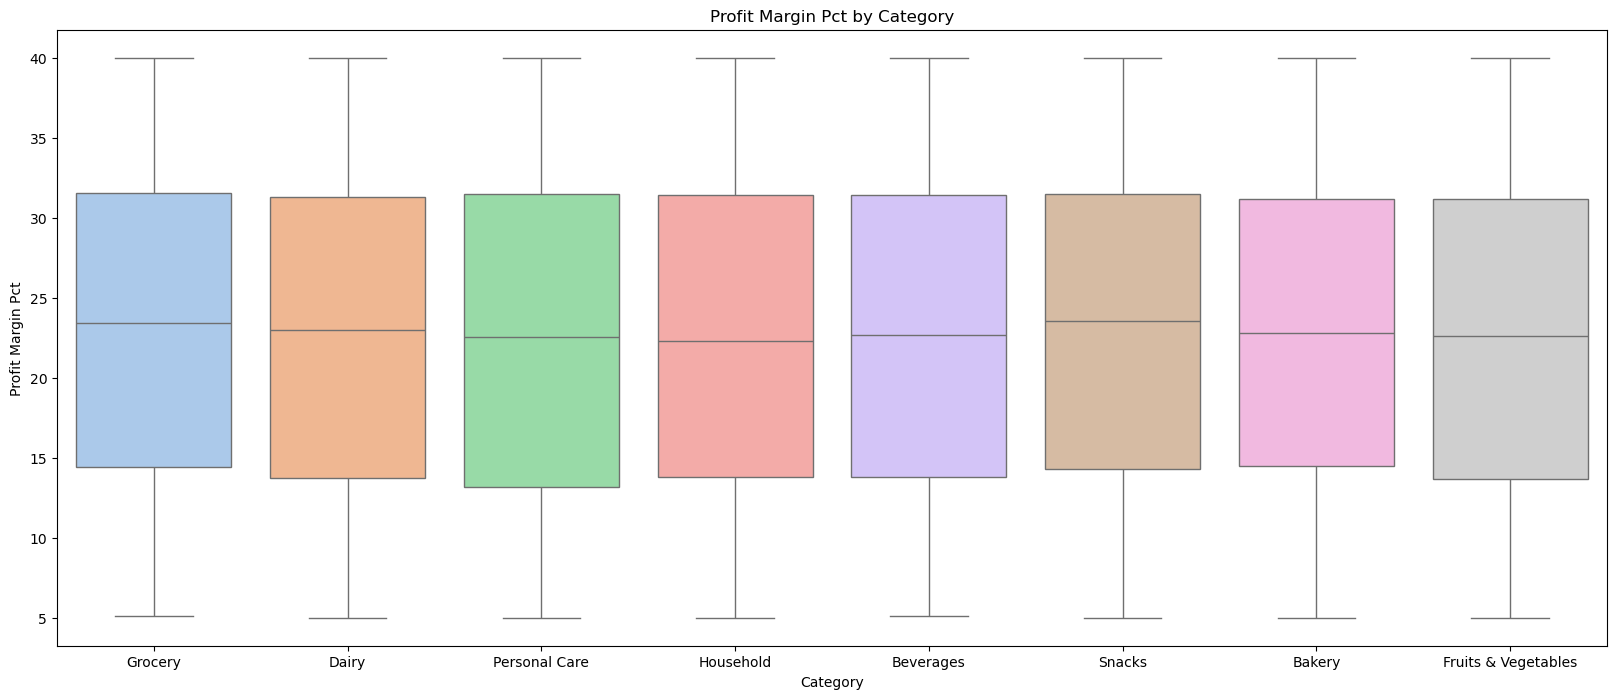

In [52]:
plt.figure(figsize=(20, 8))
sns.boxplot(x=df['category'], y=df['profit_margin_pct'], data=df, palette='pastel')
plt.title('Profit Margin Pct by Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin Pct')
plt.show()

### 7. Shelf Life Days vs Sold Quantity

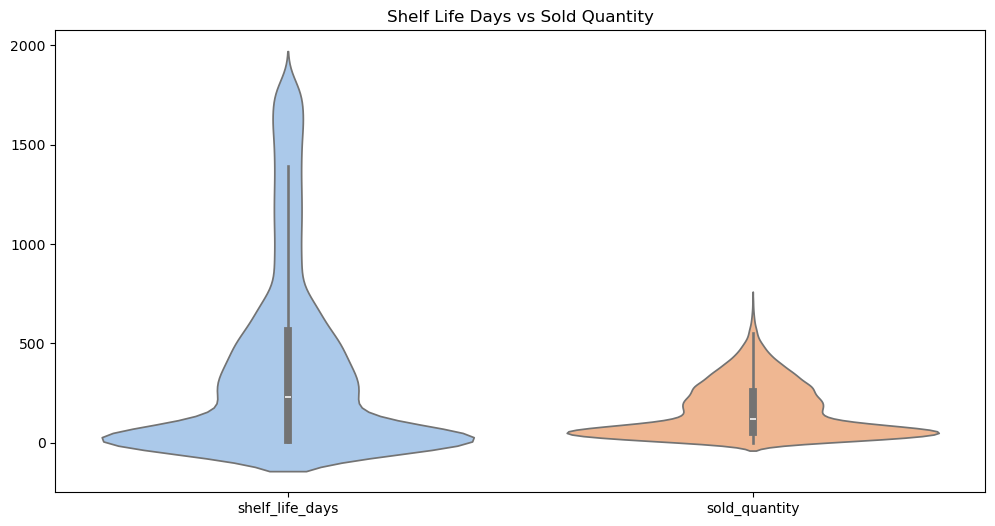

In [53]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[['shelf_life_days','sold_quantity']], palette='pastel')
plt.title('Shelf Life Days vs Sold Quantity')
plt.show()

### 8. Correlation Map

In [54]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df

,product_id,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,stock,sold_quantity,profit_margin_pct,weight_g,shelf_life_days,reorder_level,demand_index
0,1,199.78,25,149.84,4.5,146,37,76,241,29.8,750,212,15,73
1,2,44.32,30,31.02,4.0,264,36,122,28,15.2,1000,17,24,25
2,3,501.13,0,501.13,3.7,69,17,126,583,6.6,1000,1463,25,100
3,4,627.17,0,627.17,3.9,103,23,92,33,36.8,200,1143,18,15
4,5,101.69,15,86.44,4.3,422,10,152,48,14.5,300,363,30,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,219.17,15,186.29,4.8,450,30,141,202,8.3,300,482,28,73
12996,12997,348.21,5,330.80,4.5,115,25,95,63,10.5,1000,13,19,35
12997,12998,178.86,10,160.97,4.8,199,19,101,117,9.5,1000,3,20,34
12998,12999,435.70,5,413.91,3.4,114,18,123,44,38.4,500,403,24,17


In [55]:
correlation = numeric_df.corr()

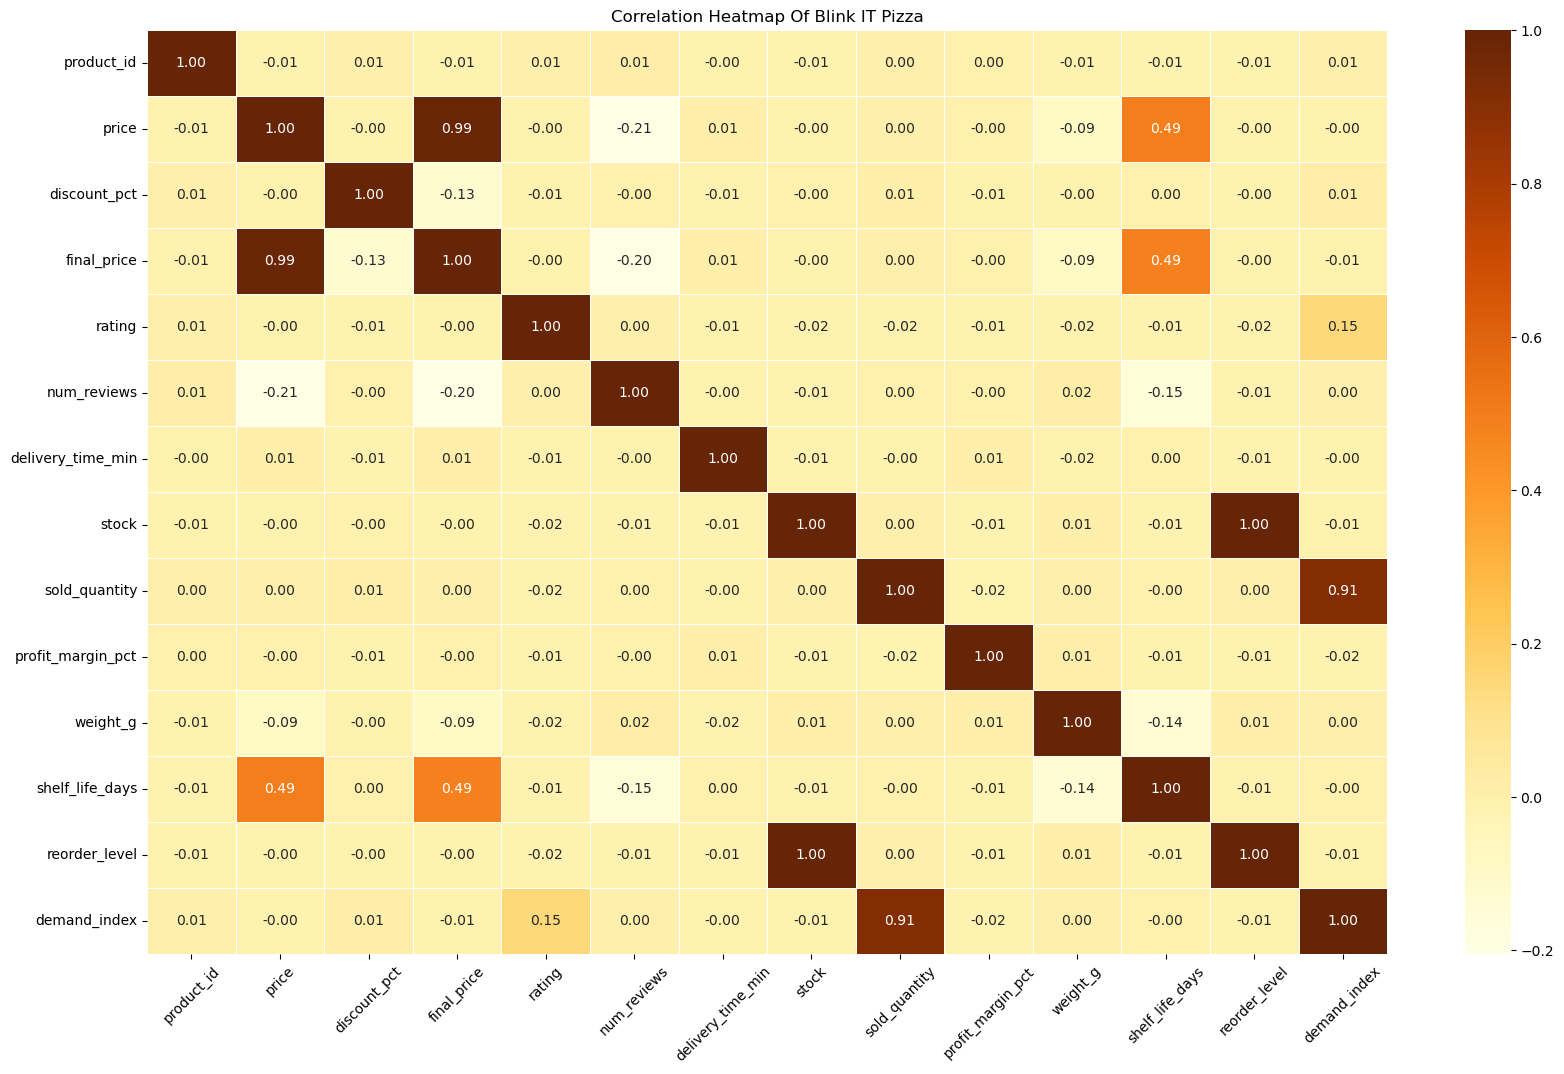

In [57]:
plt.figure(figsize=(20, 12))
sns.heatmap(correlation, annot=True, cmap='YlOrBr', fmt='.2f', linewidth=0.5)
plt.title('Correlation Heatmap Of Blink IT Pizza')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## Predictive Modeling

In [59]:
df = df.drop(['product_id'], axis = 1)
df = df.drop(['product_name'], axis = 1)
df

,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,city,seller,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,Grocery,Tata,199.78,25,149.84,4.5,146,37,Bengaluru,UrbanSeller,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,0,On-Time
1,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,Jaipur,QuickStores,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,0,Delayed
2,Personal Care,P&G,501.13,0,501.13,3.7,69,17,Chennai,QuickStores,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,Household,Dettol,627.17,0,627.17,3.9,103,23,Delhi,UrbanSeller,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,0,On-Time
4,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,Pune,UrbanSeller,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,0,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,Bengaluru,DailyNeeds,...,False,Pouch,300,482,28,73,2025-01-16,2026-05-13,0,On-Time
12996,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,Pune,DailyNeeds,...,True,Box,1000,13,19,35,2024-01-11,2024-01-24,Cashback,On-Time
12997,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,Ahmedabad,SellerB,...,True,Bottle,1000,3,20,34,2025-08-08,2025-08-11,0,On-Time
12998,Household,Lizol,435.70,5,413.91,3.4,114,18,Chennai,UrbanSeller,...,False,Bottle,500,403,24,17,2023-11-11,2024-12-18,0,On-Time


In [61]:
df['is_organic'].unique()

array([ True, False])

In [63]:
df['delivery_status'].unique()

array(['On-Time', 'Delayed'], dtype=object)

In [64]:
val = {'is_organic': {'False': 0, 'True': 1}, 
       'delivery_status': {'Delayed': 0, 'On-Time': 1}
       }
df.replace(val, inplace=True)
df

,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,city,seller,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,Grocery,Tata,199.78,25,149.84,4.5,146,37,Bengaluru,UrbanSeller,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,0,1
1,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,Jaipur,QuickStores,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,0,0
2,Personal Care,P&G,501.13,0,501.13,3.7,69,17,Chennai,QuickStores,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,1
3,Household,Dettol,627.17,0,627.17,3.9,103,23,Delhi,UrbanSeller,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,0,1
4,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,Pune,UrbanSeller,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,Bengaluru,DailyNeeds,...,False,Pouch,300,482,28,73,2025-01-16,2026-05-13,0,1
12996,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,Pune,DailyNeeds,...,True,Box,1000,13,19,35,2024-01-11,2024-01-24,Cashback,1
12997,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,Ahmedabad,SellerB,...,True,Bottle,1000,3,20,34,2025-08-08,2025-08-11,0,1
12998,Household,Lizol,435.70,5,413.91,3.4,114,18,Chennai,UrbanSeller,...,False,Bottle,500,403,24,17,2023-11-11,2024-12-18,0,1


### 1. Train Test Split

In [65]:
features = ['price', 'discount_pct', 'final_price', 'rating', 'num_reviews', 'delivery_time_min', 'stock', 'sold_quantity', 'profit_margin_pct', 'weight_g', 'shelf_life_days', 'reorder_level', 'demand_index', 'delivery_status']
target = 'is_organic'

X = df[features]
y = df[target]

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(10400, 14) (2600, 14)


### 2. Models

In [67]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decison Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [68]:
best_model = None
best_accuracy = 0
best_model_name = ''

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n {name} Accuracy: {accuracy}')


 Logistic Regression Accuracy: 0.7565384615384615

 Decison Tree Accuracy: 0.635

 Random Forest Accuracy: 0.7569230769230769

 Gradient Boosting Accuracy: 0.7542307692307693

 K-Nearest Neighbors Accuracy: 0.7007692307692308


#### Best Model

In [69]:
if accuracy > best_accuracy:
    best_accuracy = accuracy
    best_model = model
    best_model_name = name
    print(f'\n Best Model: {best_model_name} with Accuracy: {best_accuracy}')


 Best Model: K-Nearest Neighbors with Accuracy: 0.7007692307692308


### 3. Classification Report

In [70]:
y_pred_best = best_model.predict(X_test)
print(f'\n Classification Report: \n', classification_report(y_test, y_pred_best))


 Classification Report: 
               precision    recall  f1-score   support

       False       0.75      0.90      0.82      1967
        True       0.21      0.08      0.12       633

    accuracy                           0.70      2600
   macro avg       0.48      0.49      0.47      2600
weighted avg       0.62      0.70      0.65      2600



### 4. Confusion Matrix

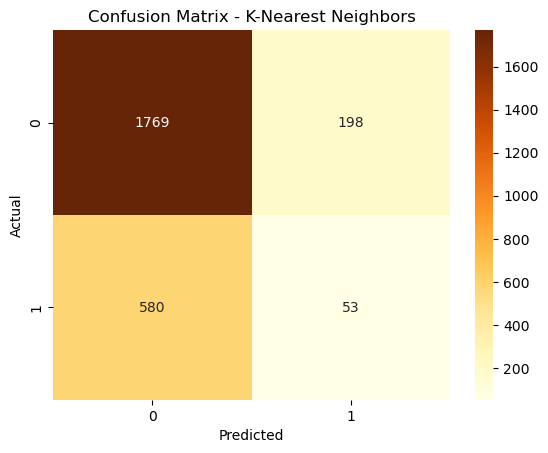

In [71]:
conf_matrix = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrBr')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()